---
title: "Clustering Analysis"
author: "Mary Piper, Lorena Pantano, Meeta Mistry, Radhika Khetani, Jihe Liu"
date: Thursday, November 21, 2019
---

Approximate time: 90 minutes

## Learning Objectives:

* Describe methods for evaluating the number of principal components used for clustering
* Perform clustering of cells based on significant principal components

# Single-cell RNA-seq clustering analysis

Now that we have our high quality cells integrated, we want to know the different cell types present within our population of cells. 

<p align="center">
<img src="../img/sc_workflow_2022.jpg" width="630">
</p>

***

_**Goals:**_ 
 
 - _To **generate cell type-specific clusters** and use known cell type marker genes to determine the identities of the clusters._
 - _To **determine whether clusters represent true cell types or cluster due to biological or technical variation**, such as clusters of cells in the S phase of the cell cycle, clusters of specific batches, or cells with high mitochondrial content._

_**Challenges:**_
 
 - _**Identifying poor quality clusters** that may be due to uninteresting biological or technical variation_
 - _**Identifying the cell types** of each cluster_
 - _Maintaining patience as this can be a highly iterative process between clustering and marker identification (sometimes even going back to the QC filtering)_

_**Recommendations:**_
 
 - _Have a good idea of your expectations for the **cell types to be present** prior to performing the clustering. Know whether you expect cell types of low complexity or higher mitochondrial content AND whether the cells are differentiating_
 - _If you have **more than one condition**, it's often helpful to perform integration to align the cells_
 - _**Regress out** number of UMIs (by default with sctransform), mitochondrial content, and cell cycle, if needed and appropriate for experiment, so not to drive clustering_
 - _Identify any junk clusters for removal or re-visit QC filtering. Possible junk clusters could include those with high **mitochondrial content** and low UMIs/genes. If comprised of a lot of cells, then may be helpful to go back to QC to filter out, then re-integrate/cluster._
 - _If **not detecting all cell types as separate clusters**, try changing the resolution or the number of PCs used for clustering_
 
***

## Clustering cells based on top PCs (metagenes)

### Set up

Before starting with this lesson, let's create a new script for the next few steps in the workflow called `clustering.ipynb`. 

Next, let's load all the libraries that we need.

In [1]:
# Single-cell RNA-seq - clustering

import scanpy as sc
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

adata_int = sc.read_h5ad("../results/08_integration.h5ad")
adata_int

AnnData object with n_obs × n_vars = 29629 × 14167
    obs: 'n_genes', 'sample', 'n_genes_by_counts', 'total_counts', 'log10GenesPerUMI', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'mito_ratio', 'S_score', 'G2M_score', 'phase', 'mitoFr', '_scvi_batch', '_scvi_labels'
    var: 'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mito', 'log1p_mean_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'id_hvg', 'log1p', 'mitoFr_colors', 'neighbors', 'pca', 'phase_colors', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_scvi', 'X_umap', '_scvi_extra_categorical_covs'
    varm: 'PCs'
    layers: 'c

## Identify significant PCs

To overcome the extensive technical noise in the expression of any single gene for scRNA-seq data, **Seurat assigns cells to clusters based on their PCA scores derived from the expression of the integrated most variable genes**, with each PC essentially representing a "metagene" that combines information across a correlated gene set. **Determining how many PCs to include in the clustering step is therefore important to ensure that we are capturing the majority of the variation**, or cell types, present in our dataset. 

It is useful to explore the PCs prior to deciding which PCs to include for the downstream clustering analysis.

(a) One way of exploring the PCs is using a heatmap to visualize the most variant genes for select PCs with the **genes and cells ordered by PCA scores**. The idea here is to look at the PCs and determine whether the genes driving them make sense for differentiating the different cell types. 

The `cells` argument specifies the number of cells with the most negative or postive PCA scores to use for the plotting. The idea is that we are looking for a PC where the heatmap starts to look more "fuzzy", i.e. where the distinctions between the groups of genes is not so distinct.


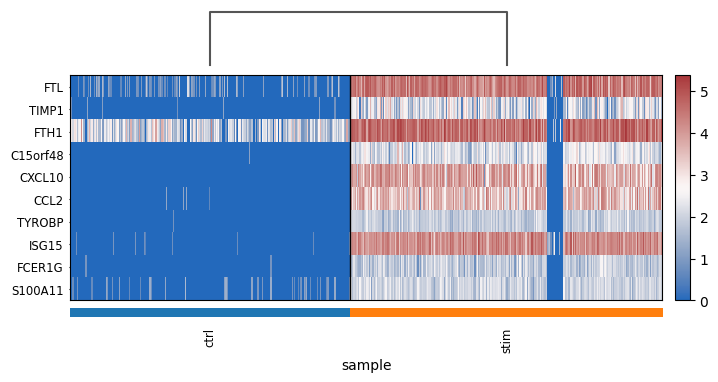

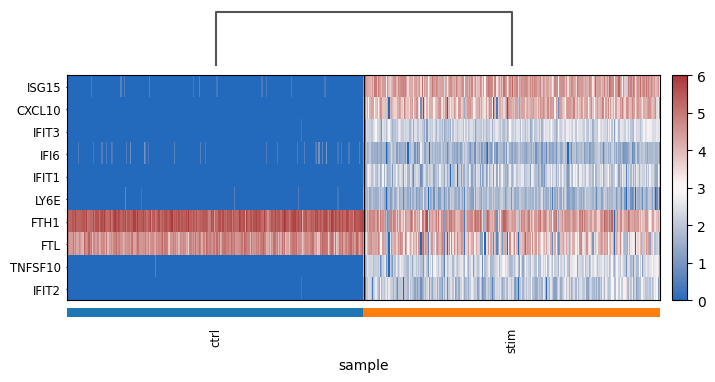

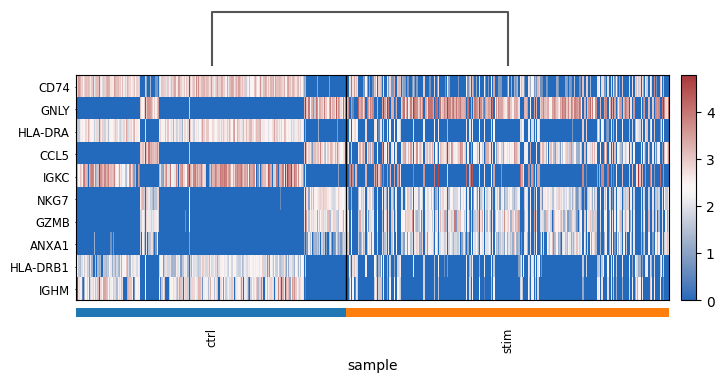

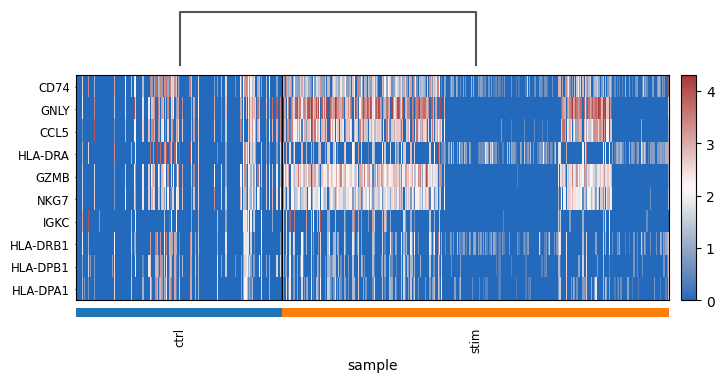

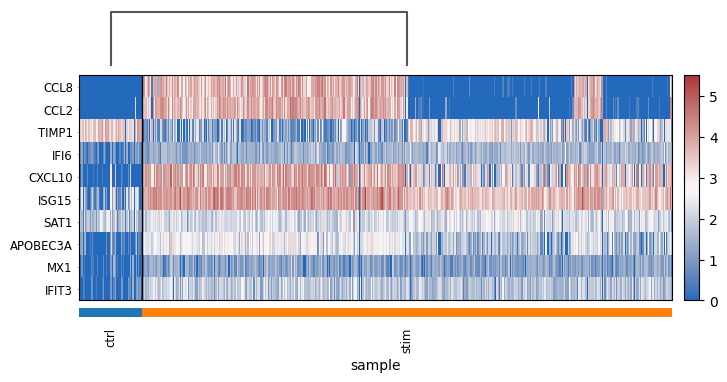

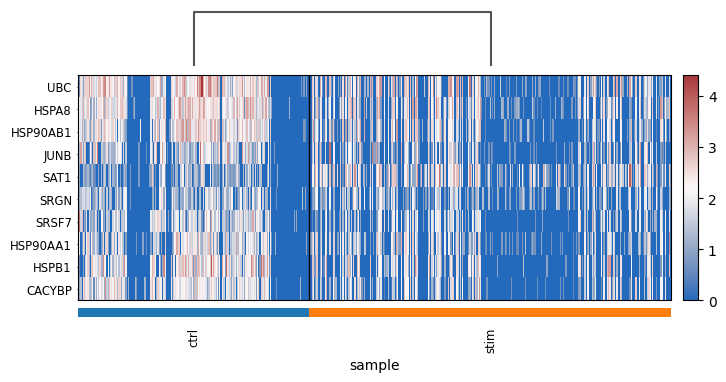

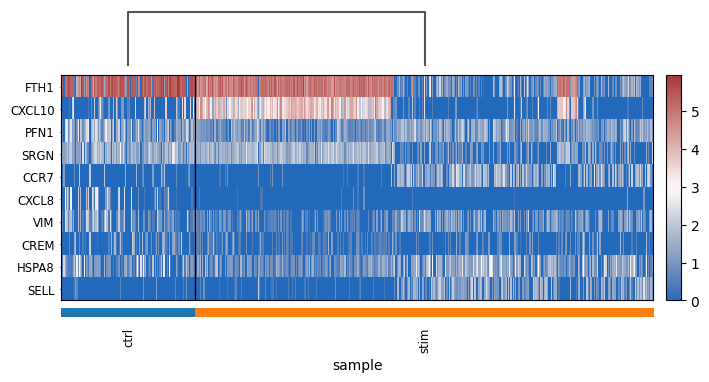

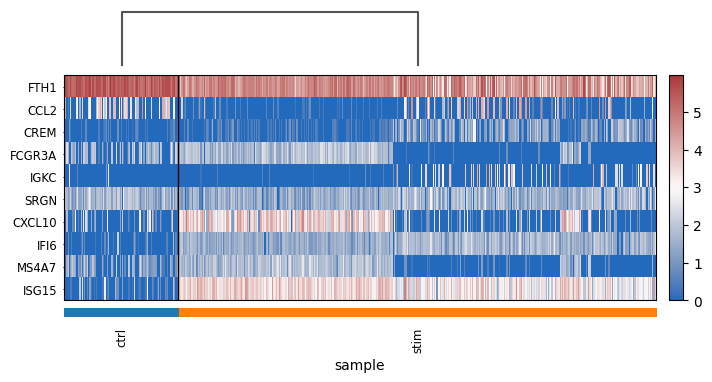

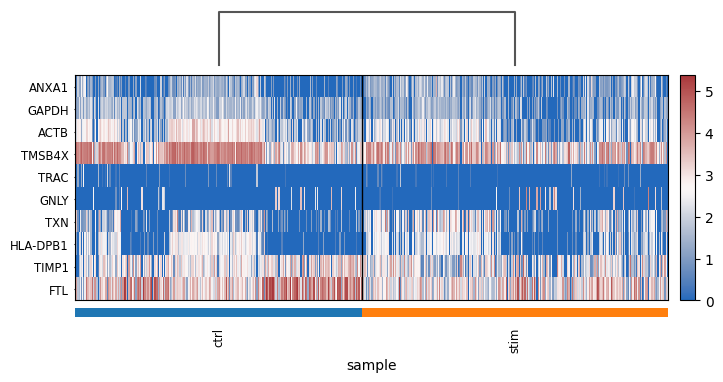

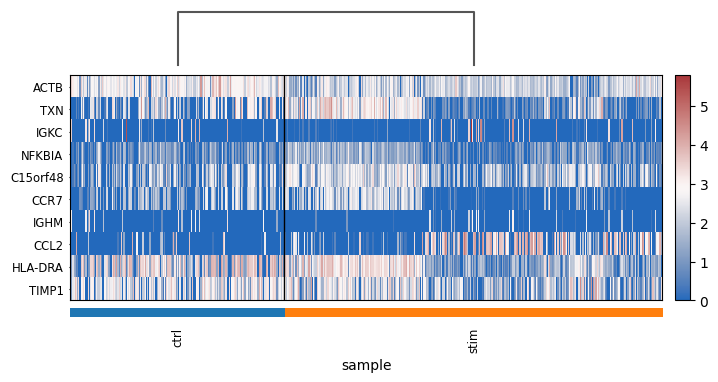

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc

num_pcs = 10               # PCs to show
genes_per_pc = 10          # Top N genes per PC
cells_per_side = 250       # Take N most + and N most - cells for PC
groupby = 'sample'        # Or whatever clustering you used

# Get PC scores for each cell: shape (n_cells, n_pcs)
X_pca = adata_int.obsm['X_pca']

for pc_ix in range(num_pcs):
    # Get PCA scores for this PC (all cells)
    pc_scores = X_pca[:, pc_ix]
    
    # Get the most positive and most negative cells
    top_idx = np.argsort(pc_scores)[-cells_per_side:]
    bottom_idx = np.argsort(pc_scores)[:cells_per_side]
    selected_cells_idx = np.concatenate([bottom_idx, top_idx])
    selected_cells = adata_int.obs_names[selected_cells_idx]
    adata_pc = adata_int[selected_cells, :].copy()  # Subsetted AnnData
    
    # Get top (absolute) loading genes for this PC
    loadings = pd.Series(adata_int.varm['PCs'][:, pc_ix], index=adata_int.var_names)
    top_genes = loadings.abs().sort_values(ascending=False).head(genes_per_pc).index.tolist()
    
    # Plot heatmap
    sc.pl.heatmap(
        adata_pc,
        var_names=top_genes,
        groupby=groupby,  # This works as long as your cluster annotation is in adata.obs[groupby]
        swap_axes=True,
        show_gene_labels=True,
        dendrogram=True,
        cmap="vlag",
        use_raw=False,  # Use adata.raw if you want raw log-normalised counts (default Scanpy workflow)
        figsize=(8, 4),
        show=True
    )

This method can be slow and hard to visualize individual genes if we would like to explore a large number of PCs. In the same vein and to explore a large number of PCs, we could print out the top 10 (or more) positive and negative genes by PCA scores driving the PCs.

In [3]:
import pandas as pd

num_pcs = 10         # How many PCs?
top_n = 10           # How many genes on each side?

for pc_ix in range(num_pcs):
    # Extract loadings for PC `pc_ix`
    loadings = pd.Series(adata_int.varm['PCs'][:, pc_ix], 
                         index=adata_int.var_names)
    # Sort to get top positive and negative drivers
    top_pos = loadings.sort_values(ascending=False).head(top_n)
    top_neg = loadings.sort_values(ascending=True).head(top_n)
    
    print(f"\nPC{pc_ix+1}:")
    print("  Top positive loading genes:")
    for gene, value in top_pos.items():
        print(f"    {gene:20} {value:.3f}")
    print("  Top negative loading genes:")
    for gene, value in top_neg.items():
        print(f"    {gene:20} {value:.3f}")


PC1:
  Top positive loading genes:
    FTL                  0.301
    TIMP1                0.211
    FTH1                 0.199
    C15orf48             0.179
    CXCL10               0.172
    CCL2                 0.166
    TYROBP               0.161
    ISG15                0.157
    FCER1G               0.145
    S100A11              0.140
  Top negative loading genes:
    CCR7                 -0.064
    TMSB4X               -0.062
    TRAC                 -0.061
    NPM1                 -0.059
    TRBC2                -0.055
    LTB                  -0.050
    TRBC1                -0.047
    SELL                 -0.037
    CCL5                 -0.037
    GNLY                 -0.032

PC2:
  Top positive loading genes:
    ISG15                0.406
    CXCL10               0.228
    IFIT3                0.217
    IFI6                 0.199
    IFIT1                0.193
    LY6E                 0.183
    TNFSF10              0.165
    IFIT2                0.155
    MX1             

(b) The **elbow plot** is another helpful way to determine how many PCs to use for clustering so that we are capturing majority of the variation in the data. The elbow plot visualizes the standard deviation of each PC, and we are looking for where the standard deviations begins to plateau. Essentially, **where the elbow appears is usually the threshold for identifying the majority of the variation**. However, this method can be quite subjective. 

Let's draw an elbow plot using the top 40 PCs:

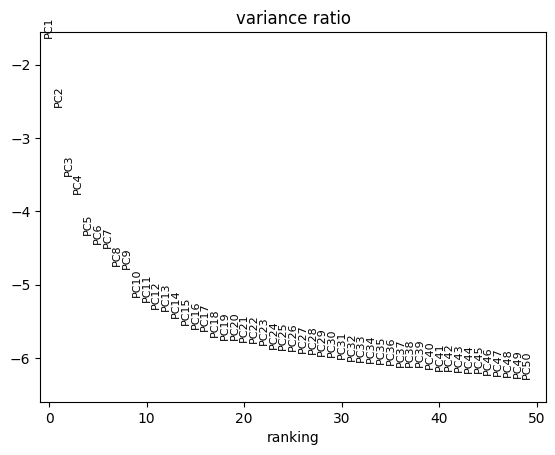

In [4]:
sc.pl.pca_variance_ratio(adata_int, n_pcs=50, log=True)

Based on this plot, we could roughly determine the majority of the variation by where the elbow occurs around PC8 - PC10, or one could argue that it should be when the data points start to get close to the X-axis, PC30 or so. This gives us a very rough idea of the number of PCs needed to be included, we can extract the information visualized here in a [**more quantitative manner**](Aside_elbow_plot_metric.qmd), which may be a bit more reliable.  

While the above 2 methods were used a lot more with older methods from Seurat for normalization and identification of variable genes, they are no longer as important as they used to be. This is because the **SCTransform method is more accurate than older methods**.

::: callout-note
# Why is selection of PCs more important for older methods?
The older methods incorporated some technical sources of variation into some of the higher PCs, so selection of PCs was more important. SCTransform estimates the variance better and does not frequently include these sources of technical variation in the higher PCs. 
 
In theory, with SCTransform, the more PCs we choose the more variation is accounted for when performing the clustering, but it takes a lot longer to perform the clustering. Therefore for this analysis, we will use the **first 40 PCs** to generate the clusters. 
:::

## Cluster the cells

Seurat uses a graph-based clustering approach using a K-nearest neighbor approach, and then attempts to partition this graph into highly interconnected ‘quasi-cliques’ or ‘communities’. A nice in-depth description of clustering methods is provided in the [SVI Bioinformatics and Cellular Genomics Lab course](https://biocellgen-public.svi.edu.au/mig_2019_scrnaseq-workshop/clustering-and-cell-annotation.html).

### Find neighbors

The first step is to **construct a K-nearest neighbor (KNN) graph** based on the euclidean distance in PCA space. 

<p align="center">
<img src="../img/k-means.png" width="500">
</p>

_Image source: [Analysis of Single cell RNA-seq data](https://biocellgen-public.svi.edu.au/mig_2019_scrnaseq-workshop/clustering-and-cell-annotation.html)_
  
  * Edges are drawn between cells with similar features expression patterns.
  * Edge weights are refined between any two cells based on shared overlap in their local neighborhoods.

This is done in Seurat by using the `sc.pp.neighbors()` function:

In [5]:
# Calculate neighbors
sc.pp.neighbors(adata_int, use_rep="X_scvi", key_added="scvi")

We specified `key_added` as "scvi" so that we do not overwrite the previous neighborhoods that were calculated with the PCA embedding. This can more clearly be seen when we look at the `obsp` slot of our adata object.

In [6]:
adata_int

AnnData object with n_obs × n_vars = 29629 × 14167
    obs: 'n_genes', 'sample', 'n_genes_by_counts', 'total_counts', 'log10GenesPerUMI', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'mito_ratio', 'S_score', 'G2M_score', 'phase', 'mitoFr', '_scvi_batch', '_scvi_labels'
    var: 'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mito', 'log1p_mean_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'id_hvg', 'log1p', 'mitoFr_colors', 'neighbors', 'pca', 'phase_colors', 'sample_colors', 'umap', 'scvi'
    obsm: 'X_pca', 'X_scvi', 'X_umap', '_scvi_extra_categorical_covs'
    varm: 'PCs'
    la

### Find clusters

Next, Seurat will **iteratively group cells together with the goal of optimizing the standard modularity function**. 

We will use the `tl.leiden()` function to perform the graph-based clustering. The `resolution` is an important argument that sets the "granularity" of the downstream clustering and will need to be optimized for every individual experiment.  For datasets of 3,000 - 5,000 cells, the `resolution` set between `0.4`-`1.4` generally yields good clustering. Increased resolution values lead to a greater number of clusters, which is often required for larger datasets. 

We will run the `tl.leiden()` function at a variety fo different resolutions. This will calculate the "granularity" of the clustering. 

In [7]:
res = 0.8
resolutions = [0.4, 0.6, 0.8, 1.0, 1.4]

for res in resolutions:
    sc.tl.leiden(adata_int, flavor="igraph", n_iterations=2, 
                 neighbors_key="scvi", resolution=res,
                key_added=f'leiden_{res}')

We can only visualize the results of one resolution setting at a time. If we look at the metadata of our AnnData object(`obs`), you should observe a separate column for each of the different resolutions calculated.

In [8]:
adata_int.obs.head()

,n_genes,sample,n_genes_by_counts,total_counts,log10GenesPerUMI,log1p_n_genes_by_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,...,G2M_score,phase,mitoFr,_scvi_batch,_scvi_labels,leiden_0.4,leiden_0.6,leiden_0.8,leiden_1.0,leiden_1.4
AAACATACAATGCC-1_ctrl,874,ctrl,874,2344.0,0.872863,6.774224,7.760041,47.568259,59.129693,69.197952,...,0.016737,G2M,Medium,0,0,0,0,0,0,0
AAACATACATTTCC-1_ctrl,896,ctrl,896,3125.0,0.844760,6.799056,8.047509,51.904000,63.456000,74.080000,...,0.003142,S,Medium,0,0,5,3,3,6,5
AAACATACCAGAAA-1_ctrl,725,ctrl,725,2578.0,0.838493,6.587550,7.855157,61.947246,69.550039,78.432894,...,-0.032831,G1,Medium,0,0,5,3,3,6,7
AAACATACCAGCTA-1_ctrl,979,ctrl,979,3261.0,0.851262,6.887553,8.090096,52.836553,62.557498,71.879791,...,-0.001563,G1,Low,0,0,6,4,5,10,10
AAACATACCATGCA-1_ctrl,362,ctrl,362,746.0,0.890686,5.894403,6.616065,53.887399,64.879357,78.284182,...,-0.032109,S,Medium high,0,0,3,5,6,2,11


## Visualize clusters of cells

To visualize the cell clusters, there are a few different dimensionality reduction techniques that can be helpful. The most popular methods include [t-distributed stochastic neighbor embedding (t-SNE)](https://kb.10xgenomics.com/hc/en-us/articles/217265066-What-is-t-Distributed-Stochastic-Neighbor-Embedding-t-SNE-) and [Uniform Manifold Approximation and Projection (UMAP)](https://umap-learn.readthedocs.io/en/latest/index.html) techniques. 

Both methods aim to place cells with similar local neighborhoods in high-dimensional space together in low-dimensional space. These methods will require you to input number of PCA dimentions to use for the visualization, we suggest using the same number of PCs as input to the clustering analysis. Here, we will proceed with the [UMAP method](https://umap-learn.readthedocs.io/en/latest/how_umap_works.html) for visualizing the clusters.

In [9]:
# Calculate UMAP
sc.tl.umap(adata_int, neighbors_key="scvi", key_added="umap_scvi")
adata_int

AnnData object with n_obs × n_vars = 29629 × 14167
    obs: 'n_genes', 'sample', 'n_genes_by_counts', 'total_counts', 'log10GenesPerUMI', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'mito_ratio', 'S_score', 'G2M_score', 'phase', 'mitoFr', '_scvi_batch', '_scvi_labels', 'leiden_0.4', 'leiden_0.6', 'leiden_0.8', 'leiden_1.0', 'leiden_1.4'
    var: 'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mito', 'log1p_mean_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'id_hvg', 'log1p', 'mitoFr_colors', 'neighbors', 'pca', 'phase_colors', 'sample_colors', 'umap', 'scvi', 'leiden_0.4', 'leiden

A good place to start is take a look again at this new UMAP distribution of our batch variable `sample`.

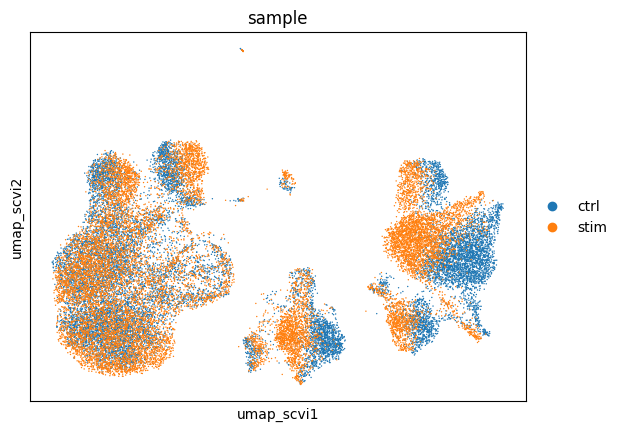

In [12]:
sc.pl.embedding(adata_int, color="sample", basis="umap_scvi")

To **choose a resolution to start with**, we often pick something in the middle of the range like 0.6 or 0.8. We will start with a resolution of 0.8 by assigning the identity of the clusters using the `color` parameter in our UMAP plotting function.

Now, we can plot the UMAP to look at how cells cluster together at a resolution of 0.8:


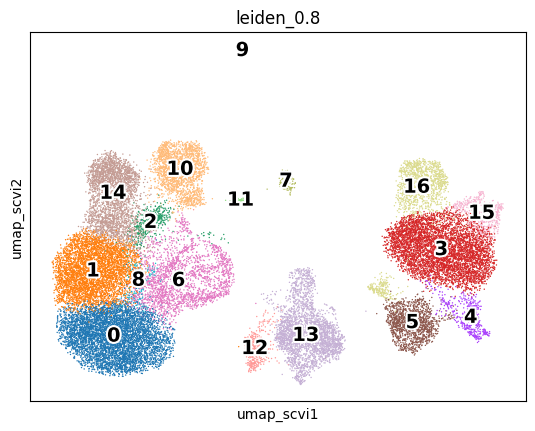

In [18]:
sc.pl.embedding(adata_int, 
                color="leiden_0.8", 
                basis="umap_scvi",
                legend_loc='on data',
                legend_fontsize=14,
                legend_fontoutline=3)

It can be useful to **explore other resolutions as well**. It will give you a quick idea about how the clusters would change based on the resolution parameter. For example, let's switch to a resolution of 0.4:

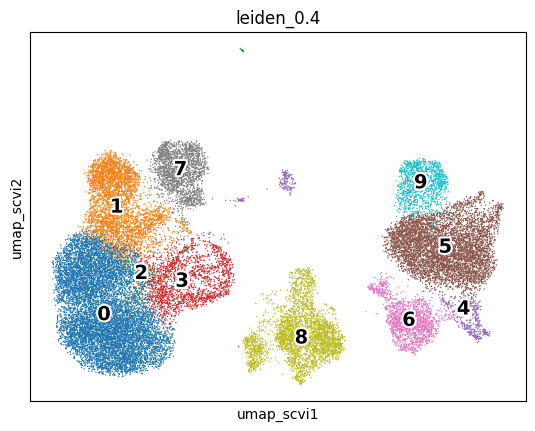

In [19]:
sc.pl.embedding(adata_int, color="leiden_0.4", 
                basis="umap_scvi",
                legend_loc='on data',
                legend_fontsize=14,
                legend_fontoutline=3)

**How does your UMAP plot compare to the one above?**

It is possible that there is some variability in the way your clusters look compared to the image in this lesson. In particular **you may see a difference in the labeling of clusters**. This is an unfortunate consequence of slight variations in the versions of packages (mostly Seurat dependencies).

**If your clusters look identical to what's in the lesson, please go ahead to the next section.**

***

**If your clusters do look different from what we have in the lesson**, please follow the instructions provided below. 

Inside your `data` folder you will see a folder called `additional_data`. It contains the seurat_integrated object that we have created for the class. 

* **Load in the object to your python session and overwrite the existing one**: 


***
::: callout-tip
# [**Exercise 1**](10_clustering_cells_SCT-Answer_key.qmd#exercise-1)

After loading `seurat_integrated.RData.bz2`, check the object clusters with different resolution (0.4, 0.6, 0.8, 1.0, 1.4). For each resolution plot the corresponding UMAP and report how many clusters you observe. Which resolution do you think makes sense?
:::

***

We will now continue with the 0.8 resolution to check the quality control metrics and known markers for the anticipated cell types. Plot the UMAP again to make sure your image now (or still) matches what you see in the lesson:
